# Лабораторная работа №2. Прогнозирование временных рядов

В работе используется набор ежедневных метеорологических наблюдений rainfall.csv. Он содержит дату, температуру (temp), точку росы, влажность, давление на уровне моря, направление и скорость ветра, солнечную радиацию, вероятность осадков и тип осадков.

Целевая переменная временного ряда — temp. Единица измерения температуры в исходном файле не указана, поэтому далее используется исходное название показателя без добавления единицы измерения.

## Задание 1. Загрузка и первичный анализ данных

Сначала данные загружаются лениво с помощью pl.scan_csv(). Затем выводятся исходная схема и количество строк.

In [1]:
import polars as pl
from pathlib import Path

FILE = Path(
    "/home/qjaricalizaya/work_university/tec-data-analisis/lab02/task/rainfall.csv"
)

data = pl.scan_csv(FILE)

initial_schema = data.collect_schema()
row_count = data.select(pl.len().alias("rows")).collect().item()

print(f"Исходная схема: {initial_schema}")
print(f"Количество строк: {row_count}")

Исходная схема: Schema({'datetime': String, 'temp': Float64, 'dew': Float64, 'humidity': Float64, 'sealevelpressure': Float64, 'winddir': Float64, 'solarradiation': Float64, 'windspeed': Float64, 'precipprob': Int64, 'preciptype': Int64})
Количество строк: 1781


### Анализ пропусков

Для каждого столбца рассчитывается доля пропущенных значений. Значение 0.0 означает, что пропусков в столбце нет.

In [2]:
missing_share = data.select(
    pl.all().is_null().mean()
).collect()

missing_share

datetime,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Во всех столбцах доля пропусков равна 0.0. Следовательно, перед анализом не требуется удалять строки или восстанавливать отсутствующие значения.

### Приведение типов и сбор данных

Столбец datetime был распознан как строка. Он преобразуется в тип Date по формату день-месяц-год. После этого данные сортируются по дате и собираются в DataFrame с помощью .collect().

In [3]:
data = (
    data
    .with_columns(
        pl.col("datetime").str.to_date("%d-%m-%Y")
    )
    .sort("datetime")
)

data_schema = data.collect_schema()
data_df = data.collect()

date_summary = data_df.select(
    pl.col("datetime").min().alias("date_min"),
    pl.col("datetime").max().alias("date_max"),
    pl.col("datetime").n_unique().alias("unique_dates"),
    (pl.col("datetime").diff().dt.total_days() != 1).sum().alias("date_gaps"),
    pl.len().alias("rows"),
)

temperature_summary = data_df.select(
    pl.col("temp").min().alias("min_temp"),
    pl.col("temp").mean().alias("mean_temp"),
    pl.col("temp").median().alias("median_temp"),
    pl.col("temp").max().alias("max_temp"),
    pl.col("temp").std().alias("std_temp"),
)

print(f"Преобразованная схема: {data_schema}")
print(date_summary)
print(temperature_summary)

Преобразованная схема: Schema({'datetime': Date, 'temp': Float64, 'dew': Float64, 'humidity': Float64, 'sealevelpressure': Float64, 'winddir': Float64, 'solarradiation': Float64, 'windspeed': Float64, 'precipprob': Int64, 'preciptype': Int64})
shape: (1, 5)
┌────────────┬────────────┬──────────────┬───────────┬──────┐
│ date_min   ┆ date_max   ┆ unique_dates ┆ date_gaps ┆ rows │
│ ---        ┆ ---        ┆ ---          ┆ ---       ┆ ---  │
│ date       ┆ date       ┆ u32          ┆ u32       ┆ u32  │
╞════════════╪════════════╪══════════════╪═══════════╪══════╡
│ 2016-01-01 ┆ 2020-11-15 ┆ 1781         ┆ 0         ┆ 1781 │
└────────────┴────────────┴──────────────┴───────────┴──────┘
shape: (1, 5)
┌──────────┬───────────┬─────────────┬──────────┬──────────┐
│ min_temp ┆ mean_temp ┆ median_temp ┆ max_temp ┆ std_temp │
│ ---      ┆ ---       ┆ ---         ┆ ---      ┆ ---      │
│ f64      ┆ f64       ┆ f64         ┆ f64      ┆ f64      │
╞══════════╪═══════════╪═════════════╪══════════╪═

После преобразования datetime имеет тип Date. Набор содержит 1 781 уникальное ежедневное наблюдение с 1 января 2016 года по 15 ноября 2020 года. Дубликатов дат и пропусков между соседними днями нет. Среднее значение temp составляет около 28.34, а значения находятся в диапазоне от 20.2 до 32.8.

## Задание 2. Визуализация данных

Для визуального исследования строится матрица рассеяния для температуры, точки росы, влажности и давления на уровне моря. На диагонали расположены гистограммы, а вне диагонали — диаграммы рассеяния с линейной линией тренда.

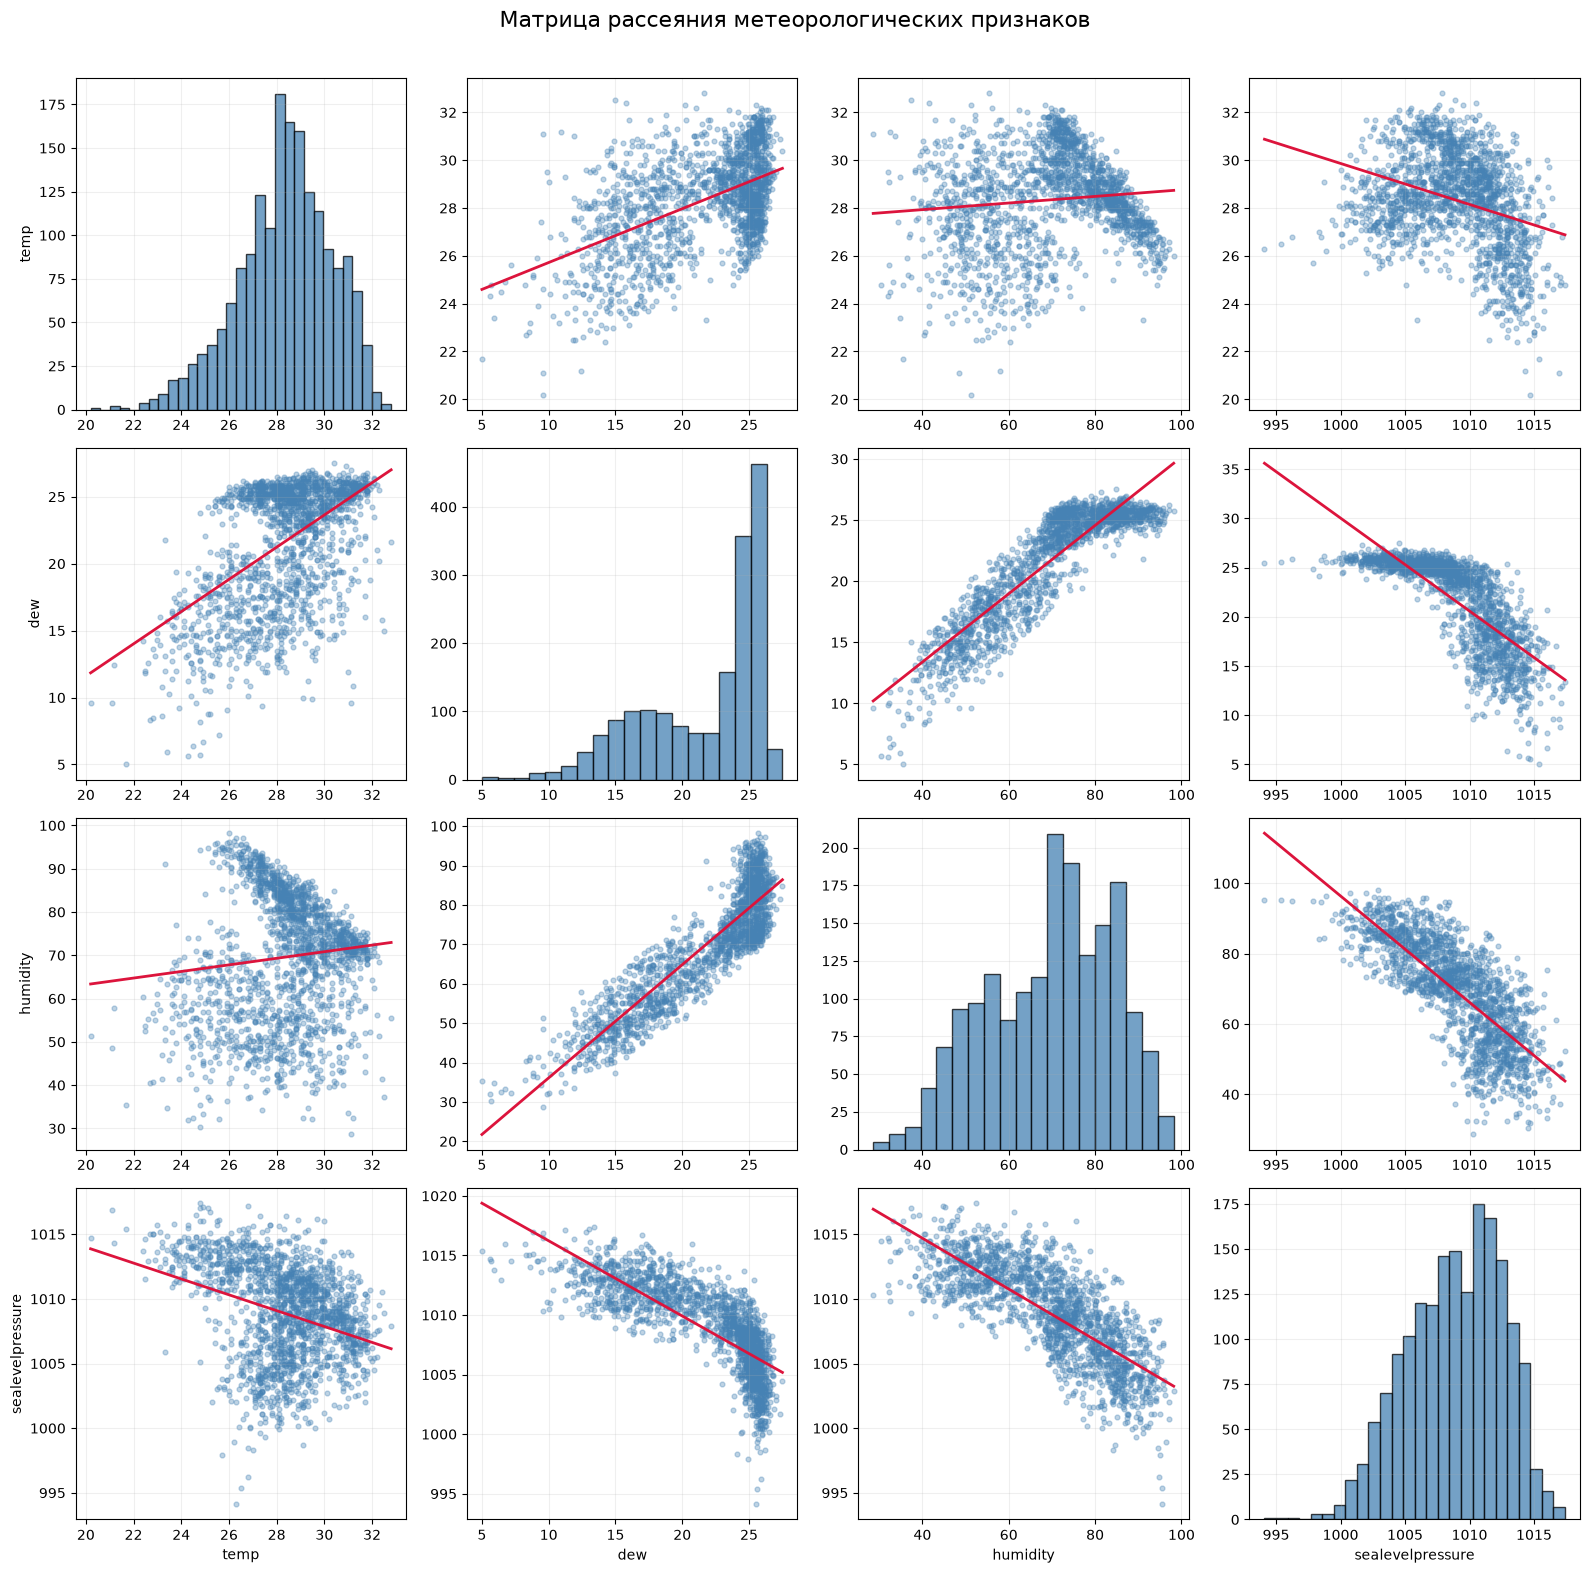

In [4]:
import numpy as np
import matplotlib.pyplot as plt

scatter_columns = [
    "temp",
    "dew",
    "humidity",
    "sealevelpressure",
]

plot_data = data_df.select(scatter_columns)
column_count = len(scatter_columns)

fig, axes = plt.subplots(
    column_count,
    column_count,
    figsize=(4 * column_count, 4 * column_count),
)

for row_index, y_column in enumerate(scatter_columns):
    for column_index, x_column in enumerate(scatter_columns):
        ax = axes[row_index, column_index]
        x = plot_data.get_column(x_column).to_numpy()
        y = plot_data.get_column(y_column).to_numpy()

        if row_index == column_index:
            ax.hist(
                x,
                bins="auto",
                color="steelblue",
                edgecolor="black",
                alpha=0.75,
            )
        else:
            ax.scatter(x, y, color="steelblue", alpha=0.35, s=12)

            valid = np.isfinite(x) & np.isfinite(y)
            x_valid = x[valid]
            y_valid = y[valid]

            if len(x_valid) >= 2 and len(np.unique(x_valid)) > 1:
                slope, intercept = np.polyfit(x_valid, y_valid, 1)
                x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
                ax.plot(
                    x_line,
                    slope * x_line + intercept,
                    color="crimson",
                    linewidth=2,
                )

        if row_index == column_count - 1:
            ax.set_xlabel(x_column)
        if column_index == 0:
            ax.set_ylabel(y_column)

        ax.grid(alpha=0.2)

fig.suptitle("Матрица рассеяния метеорологических признаков", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Корреляция признаков с температурой

Коэффициент корреляции Пирсона позволяет количественно дополнить матрицу рассеяния. Положительное значение означает совместный рост показателей, отрицательное — изменение в противоположных направлениях.

In [5]:
weather_features = [
    "dew",
    "humidity",
    "sealevelpressure",
    "winddir",
    "solarradiation",
    "windspeed",
    "precipprob",
    "preciptype",
]

correlation_with_temp = data_df.select(
    [
        pl.corr("temp", feature).alias(feature)
        for feature in weather_features
    ]
)

correlation_with_temp

dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
f64,f64,f64,f64,f64,f64,f64,f64
0.520488,0.102665,-0.32438,0.22789,0.218601,0.089735,0.133233,0.133233


Наиболее сильная положительная линейная связь наблюдается между температурой и точкой росы (r ≈ 0.52). Давление на уровне моря связано с температурой умеренно отрицательно (r ≈ -0.32). Связь с направлением ветра и солнечной радиацией слабая положительная (r ≈ 0.23 и r ≈ 0.22 соответственно). Для влажности, скорости ветра и признаков осадков линейная связь с температурой слабая (|r| < 0.14). Эти значения описывают только линейную зависимость и не доказывают причинную связь.

### График временного ряда температуры

По оси X откладывается дата, по оси Y — значение столбца temp.

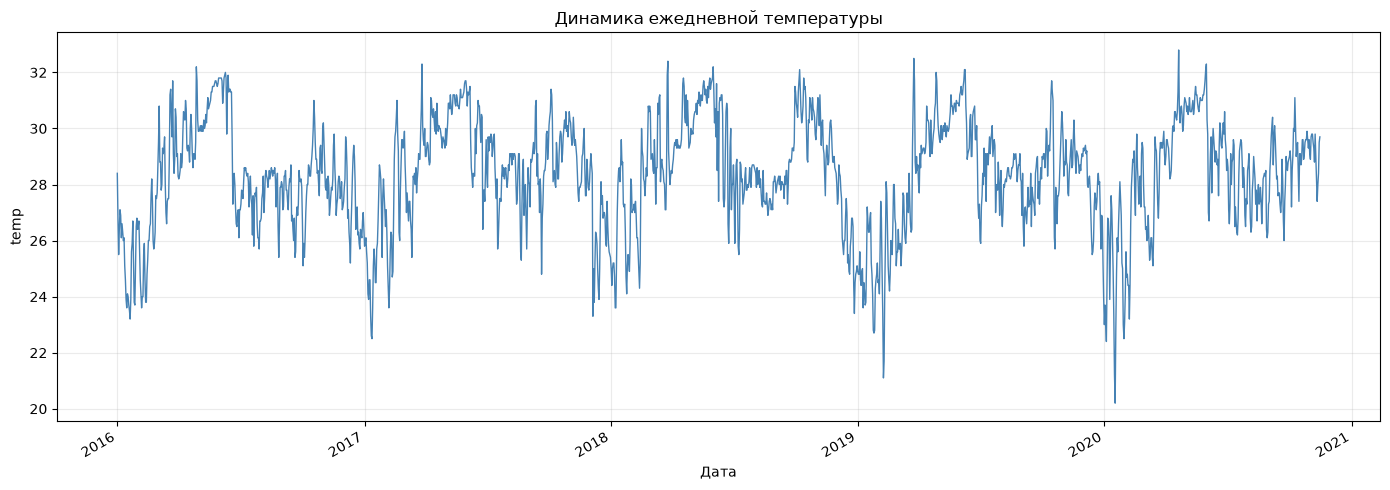

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    data_df.get_column("datetime"),
    data_df.get_column("temp"),
    color="steelblue",
    linewidth=1,
)

ax.set_title("Динамика ежедневной температуры")
ax.set_xlabel("Дата")
ax.set_ylabel("temp")
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

График показывает плавные сезонные изменения температуры и краткосрочные колебания между соседними днями. Повторяющаяся форма ряда по годам указывает на годовую сезонность, а близкие значения соседних дней предполагают положительную автокорреляцию на малых лагах.

## Задание 3. Анализ автокорреляции

Для анализа выбран полный календарный 2019 год: с 1 января по 31 декабря включительно. Это ровно 365 последовательных ежедневных наблюдений. Неполный 2020 год не используется, чтобы длина интервала не искажала сравнение лагов.

In [7]:
from datetime import date

year_data = (
    data_df
    .filter(
        pl.col("datetime").is_between(
            date(2019, 1, 1),
            date(2019, 12, 31),
        )
    )
    .sort("datetime")
)

assert year_data.height == 365, "Ожидалось 365 ежедневных наблюдений"

temperature_2019 = year_data.get_column("temp").to_numpy()

print(
    f"Период: {year_data['datetime'].min()} — "
    f"{year_data['datetime'].max()}"
)
print(f"Количество наблюдений: {year_data.height}")

Период: 2019-01-01 — 2019-12-31
Количество наблюдений: 365


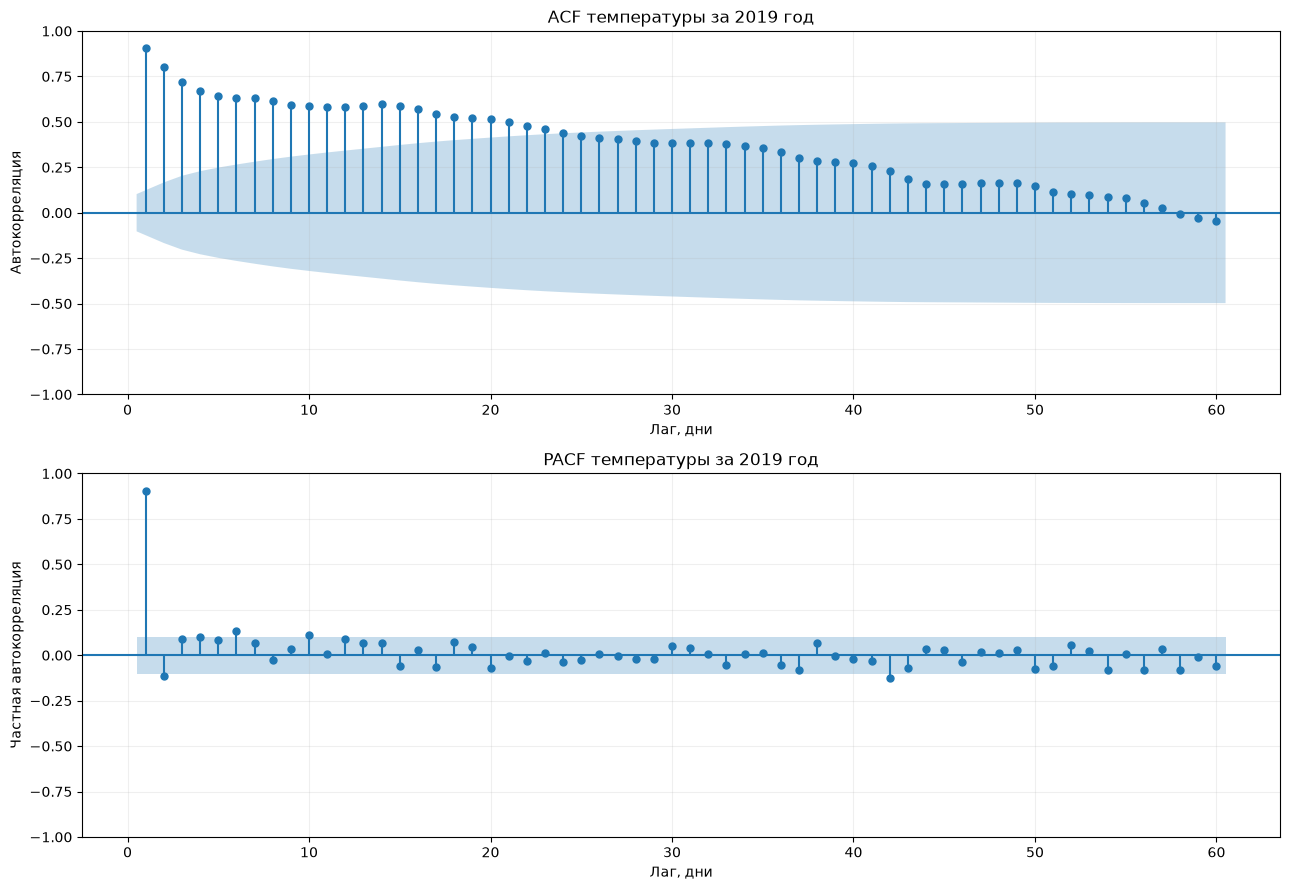

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

plot_acf(
    temperature_2019,
    lags=60,
    zero=False,
    ax=axes[0],
)
axes[0].set_title("ACF температуры за 2019 год")
axes[0].set_xlabel("Лаг, дни")
axes[0].set_ylabel("Автокорреляция")
axes[0].grid(alpha=0.2)

plot_pacf(
    temperature_2019,
    lags=60,
    zero=False,
    method="ywm",
    ax=axes[1],
)
axes[1].set_title("PACF температуры за 2019 год")
axes[1].set_xlabel("Лаг, дни")
axes[1].set_ylabel("Частная автокорреляция")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Для проверки выводов отдельно рассчитываются значения ACF и PACF на лагах 1, 7, 14, 21 и 28 дней.

In [9]:
from statsmodels.tsa.stattools import acf, pacf

acf_values = acf(temperature_2019, nlags=60, fft=True)
pacf_values = pacf(temperature_2019, nlags=60, method="ywm")

selected_lags = [1, 7, 14, 21, 28]
lag_summary = pl.DataFrame(
    {
        "lag": selected_lags,
        "ACF": [acf_values[lag] for lag in selected_lags],
        "PACF": [pacf_values[lag] for lag in selected_lags],
    }
)

lag_summary

lag,ACF,PACF
i64,f64,f64
1,0.906118,0.906118
7,0.632956,0.068934
14,0.600983,0.066305
21,0.499393,-0.004984
28,0.396491,-0.018829


### Выводы по ACF и PACF

1. **Недельная сезонность.** ACF равна примерно 0.63, 0.60, 0.50 и 0.40 на лагах 7, 14, 21 и 28. Однако на этих лагах нет регулярной последовательности выраженных локальных пиков. Корреляция в целом медленно уменьшается с ростом лага. Поэтому убедительных признаков недельной сезонности нет; высокие значения скорее отражают инерционность температуры и более медленную сезонную динамику.

2. **AR(1)-структура.** PACF имеет очень высокий первый лаг (≈ 0.91), после которого значения резко уменьшаются. На втором лаге значение около -0.11, а большинство последующих значений близки к нулю. Это указывает на доминирующую зависимость от предыдущего дня и в целом согласуется с AR(1)-подобной структурой, хотя ряд нельзя считать идеальной чистой моделью AR(1).

Таким образом, температура обладает сильной краткосрочной зависимостью: значение текущего дня тесно связано со значением предыдущего дня. Чёткий недельный цикл для данного ряда не обнаружен.

## Задание 4. Создание базовых признаков

сортировка данных по времени
Создание лаги: lag_1, lag_7, lag_14, lag_30.

In [10]:
sorted_data_by_time = data_df.sort("datetime") 
data_lags = sorted_data_by_time.select(
    pl.col("datetime"),
    pl.col("temp").alias("current temperature"),
    pl.col("temp").shift(1).alias("lag_1"),
    pl.col("temp").shift(7).alias("lag_7"),
    pl.col("temp").shift(14).alias("lag_14"),
    pl.col("temp").shift(30).alias("lag_30"),
    
)



print(data_lags)

shape: (1_781, 6)
┌────────────┬─────────────────────┬───────┬───────┬────────┬────────┐
│ datetime   ┆ current temperature ┆ lag_1 ┆ lag_7 ┆ lag_14 ┆ lag_30 │
│ ---        ┆ ---                 ┆ ---   ┆ ---   ┆ ---    ┆ ---    │
│ date       ┆ f64                 ┆ f64   ┆ f64   ┆ f64    ┆ f64    │
╞════════════╪═════════════════════╪═══════╪═══════╪════════╪════════╡
│ 2016-01-01 ┆ 28.4                ┆ null  ┆ null  ┆ null   ┆ null   │
│ 2016-01-02 ┆ 26.8                ┆ 28.4  ┆ null  ┆ null   ┆ null   │
│ 2016-01-03 ┆ 25.5                ┆ 26.8  ┆ null  ┆ null   ┆ null   │
│ 2016-01-04 ┆ 26.4                ┆ 25.5  ┆ null  ┆ null   ┆ null   │
│ 2016-01-05 ┆ 27.1                ┆ 26.4  ┆ null  ┆ null   ┆ null   │
│ …          ┆ …                   ┆ …     ┆ …     ┆ …      ┆ …      │
│ 2020-11-11 ┆ 27.4                ┆ 28.1  ┆ 29.8  ┆ 29.6   ┆ 29.3   │
│ 2020-11-12 ┆ 28.0                ┆ 27.4  ┆ 29.5  ┆ 29.3   ┆ 29.5   │
│ 2020-11-13 ┆ 28.4                ┆ 28.0  ┆ 29.3  ┆ 29.6  

разности: diff_1 (y_t - y_{t-1}), diff_7.

In [11]:
data_lags_diff = sorted_data_by_time.select( 
    pl.col("datetime"), 
    pl.col("temp").alias("current temperature"),
    pl.col("temp").diff(1).alias("diff_1"),
    pl.col("temp").diff(7).alias("diff_7"),
    #pl.col("temp").diff(14).alias("diff_14"),  
    #pl.col("temp").diff(30).alias("diff_30"),

    
)

print(data_lags_diff)

shape: (1_781, 4)
┌────────────┬─────────────────────┬────────┬────────┐
│ datetime   ┆ current temperature ┆ diff_1 ┆ diff_7 │
│ ---        ┆ ---                 ┆ ---    ┆ ---    │
│ date       ┆ f64                 ┆ f64    ┆ f64    │
╞════════════╪═════════════════════╪════════╪════════╡
│ 2016-01-01 ┆ 28.4                ┆ null   ┆ null   │
│ 2016-01-02 ┆ 26.8                ┆ -1.6   ┆ null   │
│ 2016-01-03 ┆ 25.5                ┆ -1.3   ┆ null   │
│ 2016-01-04 ┆ 26.4                ┆ 0.9    ┆ null   │
│ 2016-01-05 ┆ 27.1                ┆ 0.7    ┆ null   │
│ …          ┆ …                   ┆ …      ┆ …      │
│ 2020-11-11 ┆ 27.4                ┆ -0.7   ┆ -2.4   │
│ 2020-11-12 ┆ 28.0                ┆ 0.6    ┆ -1.5   │
│ 2020-11-13 ┆ 28.4                ┆ 0.4    ┆ -0.9   │
│ 2020-11-14 ┆ 29.5                ┆ 1.1    ┆ 0.7    │
│ 2020-11-15 ┆ 29.7                ┆ 0.2    ┆ -0.1   │
└────────────┴─────────────────────┴────────┴────────┘


объединение таблиц и добавлние ratio_7 (y_t / y_{t-7}).

In [12]:
data_lags = data_lags.join(data_lags_diff, on="datetime", suffix="_diff") 

#data_lags.drop("current temperature_diff")



data_lags_ratio = data_lags.with_columns(
    #(pl.col("current temperature") / pl.col("lag_1") ) .alias("ratio_1"),
    (pl.col("current temperature") / pl.col("lag_7") ) .alias("ratio_7"),
    #(pl.col("current temperature") / pl.col("lag_14") ) .alias("ratio_14"),
    #(pl.col("current temperature") / pl.col("lag_30") ) .alias("ratio_30")
)

print(data_lags_ratio)


shape: (1_781, 10)
┌────────────┬─────────────┬───────┬───────┬───┬──────────────────┬────────┬────────┬──────────┐
│ datetime   ┆ current     ┆ lag_1 ┆ lag_7 ┆ … ┆ current          ┆ diff_1 ┆ diff_7 ┆ ratio_7  │
│ ---        ┆ temperature ┆ ---   ┆ ---   ┆   ┆ temperature_diff ┆ ---    ┆ ---    ┆ ---      │
│ date       ┆ ---         ┆ f64   ┆ f64   ┆   ┆ ---              ┆ f64    ┆ f64    ┆ f64      │
│            ┆ f64         ┆       ┆       ┆   ┆ f64              ┆        ┆        ┆          │
╞════════════╪═════════════╪═══════╪═══════╪═══╪══════════════════╪════════╪════════╪══════════╡
│ 2016-01-01 ┆ 28.4        ┆ null  ┆ null  ┆ … ┆ 28.4             ┆ null   ┆ null   ┆ null     │
│ 2016-01-02 ┆ 26.8        ┆ 28.4  ┆ null  ┆ … ┆ 26.8             ┆ -1.6   ┆ null   ┆ null     │
│ 2016-01-03 ┆ 25.5        ┆ 26.8  ┆ null  ┆ … ┆ 25.5             ┆ -1.3   ┆ null   ┆ null     │
│ 2016-01-04 ┆ 26.4        ┆ 25.5  ┆ null  ┆ … ┆ 26.4             ┆ 0.9    ┆ null   ┆ null     │
│ 2016-01-0

подготовка дата для моделя 
- разделение данные на обучающую (train) и тестовую (test) выборки по дате.
- выборка размеры матриц признаков X_train и X_test, а также целевых векторов y_train и y_test.

In [13]:
model_data = data_lags_ratio.drop_nulls().select(["datetime","current temperature","lag_1", "lag_7", "lag_14", "lag_30", "diff_1", "diff_7", "ratio_7"])


target = "current temperature"
feature = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "diff_1",
    "diff_7",
    "ratio_7"
]
split_date = date(2019, 1, 1)

train = model_data.filter(pl.col("datetime") < split_date)
test = model_data.filter(pl.col("datetime") >= split_date)


X_train = train.select(feature).to_numpy()
y_train = train.get_column(target).to_numpy()

X_test = test.select(feature).to_numpy()
y_test = test.get_column(target).to_numpy()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)




(1066, 7) (1066,)
(685, 7) (685,)


## Задание 5. Создание продвинутых признаков

Добавьте календарные признаки: dayofweek, month, quarter, dayofyear, weekofyear, day

In [14]:
extra_data = model_data.with_columns(
  
    pl.col("datetime").dt.weekday().alias("dayofweek"),
    pl.col("datetime").dt.month().alias("month"),
    pl.col("datetime").dt.quarter().alias("quarter"),
    pl.col("datetime").dt.ordinal_day().alias("dayofyear"),
    pl.col("datetime").dt.week().alias("weekofyear"),
    pl.col("datetime").dt.day().alias("day")

 )

print(extra_data)

shape: (1_751, 15)
┌────────────┬─────────────────────┬───────┬───────┬───┬─────────┬───────────┬────────────┬─────┐
│ datetime   ┆ current temperature ┆ lag_1 ┆ lag_7 ┆ … ┆ quarter ┆ dayofyear ┆ weekofyear ┆ day │
│ ---        ┆ ---                 ┆ ---   ┆ ---   ┆   ┆ ---     ┆ ---       ┆ ---        ┆ --- │
│ date       ┆ f64                 ┆ f64   ┆ f64   ┆   ┆ i8      ┆ i16       ┆ i8         ┆ i8  │
╞════════════╪═════════════════════╪═══════╪═══════╪═══╪═════════╪═══════════╪════════════╪═════╡
│ 2016-01-31 ┆ 26.4                ┆ 26.8  ┆ 26.7  ┆ … ┆ 1       ┆ 31        ┆ 4          ┆ 31  │
│ 2016-02-01 ┆ 26.5                ┆ 26.4  ┆ 25.2  ┆ … ┆ 1       ┆ 32        ┆ 5          ┆ 1   │
│ 2016-02-02 ┆ 26.7                ┆ 26.5  ┆ 23.8  ┆ … ┆ 1       ┆ 33        ┆ 5          ┆ 2   │
│ 2016-02-03 ┆ 25.7                ┆ 26.7  ┆ 23.7  ┆ … ┆ 1       ┆ 34        ┆ 5          ┆ 3   │
│ 2016-02-04 ┆ 24.6                ┆ 25.7  ┆ 25.1  ┆ … ┆ 1       ┆ 35        ┆ 5          ┆ 4   │
│

Преобразование циклических признаков с помощью sin/cos:

In [15]:
week_period = 7
month_period = 12
year_period = 365.25

extra_data = extra_data.with_columns(
    ( 2 * np.pi * pl.col("dayofweek") / week_period ).sin().alias("dow_sin"),
    ( 2 * np.pi * pl.col("dayofweek") / week_period ).cos().alias("dow_cos"),

    ( 2 * np.pi * pl.col("month") / month_period ).sin().alias("month_sin"),
    ( 2 * np.pi * pl.col("month") / month_period ).cos().alias("month_cos"),

    ( 2 * np.pi * pl.col("dayofyear") / year_period ).sin().alias("doy_sin"),
    ( 2 * np.pi * pl.col("dayofyear") / year_period ).cos().alias("doy_cos")

)
#extra_data.write_csv("/home/qjaricalizaya/work_university/tec-data-analisis/lab02/task/extra_data.csv")

#print(extra_data["month", "month_sin", "month_cos"][30:40])
print(extra_data)

shape: (1_751, 21)
┌────────────┬─────────────┬───────┬───────┬───┬───────────┬───────────┬───────────┬──────────┐
│ datetime   ┆ current     ┆ lag_1 ┆ lag_7 ┆ … ┆ month_sin ┆ month_cos ┆ doy_sin   ┆ doy_cos  │
│ ---        ┆ temperature ┆ ---   ┆ ---   ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ date       ┆ ---         ┆ f64   ┆ f64   ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│            ┆ f64         ┆       ┆       ┆   ┆           ┆           ┆           ┆          │
╞════════════╪═════════════╪═══════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2016-01-31 ┆ 26.4        ┆ 26.8  ┆ 26.7  ┆ … ┆ 0.5       ┆ 0.866025  ┆ 0.508356  ┆ 0.861147 │
│ 2016-02-01 ┆ 26.5        ┆ 26.4  ┆ 25.2  ┆ … ┆ 0.866025  ┆ 0.5       ┆ 0.523094  ┆ 0.852275 │
│ 2016-02-02 ┆ 26.7        ┆ 26.5  ┆ 23.8  ┆ … ┆ 0.866025  ┆ 0.5       ┆ 0.537677  ┆ 0.843151 │
│ 2016-02-03 ┆ 25.7        ┆ 26.7  ┆ 23.7  ┆ … ┆ 0.866025  ┆ 0.5       ┆ 0.552101  ┆ 0.833777 │
│ 2016-02-04 ┆ 24.6  

Создание Fourier‑признаков для недельной сезонности (k=1,2,3) и годовой сезонности (k=1,2,3).

In [16]:
# t representa el avance continuo de los días en la serie temporal.
extra_data = extra_data.with_row_index("time_index")

fourier_features = []
fourier_names = []

for k in range(1, 4):
    names = [
        f"fourier_week_sin_{k}",
        f"fourier_week_cos_{k}",
        f"fourier_year_sin_{k}",
        f"fourier_year_cos_{k}",
    ]

    fourier_features.extend([
        (2 * np.pi * k * pl.col("time_index") / week_period).sin().alias(names[0]),
        (2 * np.pi * k * pl.col("time_index") / week_period).cos().alias(names[1]),
        (2 * np.pi * k * pl.col("time_index") / year_period).sin().alias(names[2]),
        (2 * np.pi * k * pl.col("time_index") / year_period).cos().alias(names[3]),
    ])
    fourier_names.extend(names)

extra_data = (
    extra_data
    .with_columns(fourier_features)
    .drop("time_index")
)

print(extra_data.select(["datetime", *fourier_names]))

shape: (1_751, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ datetime  ┆ fourier_w ┆ fourier_w ┆ fourier_y ┆ … ┆ fourier_w ┆ fourier_w ┆ fourier_y ┆ fourier_ │
│ ---       ┆ eek_sin_1 ┆ eek_cos_1 ┆ ear_sin_1 ┆   ┆ eek_sin_3 ┆ eek_cos_3 ┆ ear_sin_3 ┆ year_cos │
│ date      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ _3       │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2016-01-3 ┆ 0.0       ┆ 1.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 1.0       ┆ 0.0       ┆ 1.0      │
│ 1         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 2016-02-0 ┆ 0.781831  ┆ 0.62349   ┆ 0.017202  ┆ … ┆ 0.433884  ┆ -0.900

Добавление скользящих статистик:

In [17]:
extra_data = extra_data.with_columns(

        pl.col("current temperature").rolling_mean(window_size=7).alias("roll_mean_7"),
        pl.col("current temperature").rolling_mean(window_size=30).alias("roll_mean_30"),

        pl.col("current temperature").rolling_std(window_size=7).alias("roll_std_7"),
        pl.col("current temperature").rolling_std(window_size=30).alias("roll_std_30"),

        pl.col("current temperature").rolling_min(window_size=7).alias("roll_min_7"),
        pl.col("current temperature").rolling_max(window_size=7).alias("roll_max_7"),    


)
print(extra_data.select(["datetime", "roll_mean_7", "roll_mean_30", "roll_std_7", "roll_std_30", "roll_min_7", "roll_max_7"]))

shape: (1_751, 7)
┌────────────┬─────────────┬──────────────┬────────────┬─────────────┬────────────┬────────────┐
│ datetime   ┆ roll_mean_7 ┆ roll_mean_30 ┆ roll_std_7 ┆ roll_std_30 ┆ roll_min_7 ┆ roll_max_7 │
│ ---        ┆ ---         ┆ ---          ┆ ---        ┆ ---         ┆ ---        ┆ ---        │
│ date       ┆ f64         ┆ f64          ┆ f64        ┆ f64         ┆ f64        ┆ f64        │
╞════════════╪═════════════╪══════════════╪════════════╪═════════════╪════════════╪════════════╡
│ 2016-01-31 ┆ null        ┆ null         ┆ null       ┆ null        ┆ null       ┆ null       │
│ 2016-02-01 ┆ null        ┆ null         ┆ null       ┆ null        ┆ null       ┆ null       │
│ 2016-02-02 ┆ null        ┆ null         ┆ null       ┆ null        ┆ null       ┆ null       │
│ 2016-02-03 ┆ null        ┆ null         ┆ null       ┆ null        ┆ null       ┆ null       │
│ 2016-02-04 ┆ null        ┆ null         ┆ null       ┆ null        ┆ null       ┆ null       │
│ …         

EWMA (ewma_7, ewma_30, ewma_90).

In [18]:
extra_data = extra_data.with_columns(

    pl.col("current temperature").ewm_mean(span=7).alias("ewma_7"),
    pl.col("current temperature").ewm_mean(span=30).alias("ewma_30"),
    pl.col("current temperature").ewm_mean(span=90).alias("ewma_90"),
)
print(extra_data.select(["datetime", "ewma_7", "ewma_30", "ewma_90"]))

shape: (1_751, 4)
┌────────────┬───────────┬───────────┬───────────┐
│ datetime   ┆ ewma_7    ┆ ewma_30   ┆ ewma_90   │
│ ---        ┆ ---       ┆ ---       ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╡
│ 2016-01-31 ┆ 26.4      ┆ 26.4      ┆ 26.4      │
│ 2016-02-01 ┆ 26.457143 ┆ 26.451667 ┆ 26.450556 │
│ 2016-02-02 ┆ 26.562162 ┆ 26.540022 ┆ 26.535558 │
│ 2016-02-03 ┆ 26.246857 ┆ 26.308565 ┆ 26.319655 │
│ 2016-02-04 ┆ 25.707042 ┆ 25.919825 ┆ 25.96027  │
│ …          ┆ …         ┆ …         ┆ …         │
│ 2020-11-11 ┆ 28.615388 ┆ 29.067792 ┆ 28.818495 │
│ 2020-11-12 ┆ 28.461541 ┆ 28.998903 ┆ 28.800506 │
│ 2020-11-13 ┆ 28.446156 ┆ 28.960264 ┆ 28.791704 │
│ 2020-11-14 ┆ 28.709617 ┆ 28.995085 ┆ 28.807271 │
│ 2020-11-15 ┆ 28.957213 ┆ 29.040564 ┆ 28.826891 │
└────────────┴───────────┴───────────┴───────────┘


Создайте дополнительные признаки:
- отклонение от EWMA (dev_ewma_30)

In [19]:
extra_data = extra_data.with_columns(
  (  pl.col("current temperature") - pl.col("ewma_30") ).alias("dev_ewma_30")
)

- отношение скользящих средних (ratio_roll_7_30);

In [20]:
extra_data = extra_data.with_columns(
    (pl.col("roll_mean_7") / pl.col("roll_mean_30") ).alias("ratio_roll_7_30")
)

- z‑score (zscore_30)

In [21]:
extra_data = extra_data.with_columns(
  ( ( pl.col("current temperature") - pl.col("roll_mean_30") ) / pl.col("roll_std_30")).alias("zscore_30")
)

print(extra_data.select(["datetime", "dev_ewma_30", "ratio_roll_7_30", "zscore_30"]))

shape: (1_751, 4)
┌────────────┬─────────────┬─────────────────┬───────────┐
│ datetime   ┆ dev_ewma_30 ┆ ratio_roll_7_30 ┆ zscore_30 │
│ ---        ┆ ---         ┆ ---             ┆ ---       │
│ date       ┆ f64         ┆ f64             ┆ f64       │
╞════════════╪═════════════╪═════════════════╪═══════════╡
│ 2016-01-31 ┆ 0.0         ┆ null            ┆ null      │
│ 2016-02-01 ┆ 0.048333    ┆ null            ┆ null      │
│ 2016-02-02 ┆ 0.159978    ┆ null            ┆ null      │
│ 2016-02-03 ┆ -0.608565   ┆ null            ┆ null      │
│ 2016-02-04 ┆ -1.319825   ┆ null            ┆ null      │
│ …          ┆ …           ┆ …               ┆ …         │
│ 2020-11-11 ┆ -1.667792   ┆ 0.989237        ┆ -2.736137 │
│ 2020-11-12 ┆ -0.998903   ┆ 0.983574        ┆ -1.646654 │
│ 2020-11-13 ┆ -0.560264   ┆ 0.979269        ┆ -1.041324 │
│ 2020-11-14 ┆ 0.504915    ┆ 0.980347        ┆ 0.547106  │
│ 2020-11-15 ┆ 0.659436    ┆ 0.979186        ┆ 0.8381    │
└────────────┴─────────────┴──────────

Добавьте категориальные признаки: is_weekend, is_winter.

In [22]:
extra_data = extra_data.with_columns(
    (pl.col("dayofweek").is_in([6,7]) ).cast(pl.Int8)  .alias("is_weekend"),
    (pl.col("month").is_in([12, 1, 2]) ).cast(pl.Int8)  .alias("is_winter")
)

print(extra_data.select(["datetime", "dayofweek", "is_weekend", "month" , "is_winter" ]))

shape: (1_751, 5)
┌────────────┬───────────┬────────────┬───────┬───────────┐
│ datetime   ┆ dayofweek ┆ is_weekend ┆ month ┆ is_winter │
│ ---        ┆ ---       ┆ ---        ┆ ---   ┆ ---       │
│ date       ┆ i8        ┆ i8         ┆ i8    ┆ i8        │
╞════════════╪═══════════╪════════════╪═══════╪═══════════╡
│ 2016-01-31 ┆ 7         ┆ 1          ┆ 1     ┆ 1         │
│ 2016-02-01 ┆ 1         ┆ 0          ┆ 2     ┆ 1         │
│ 2016-02-02 ┆ 2         ┆ 0          ┆ 2     ┆ 1         │
│ 2016-02-03 ┆ 3         ┆ 0          ┆ 2     ┆ 1         │
│ 2016-02-04 ┆ 4         ┆ 0          ┆ 2     ┆ 1         │
│ …          ┆ …         ┆ …          ┆ …     ┆ …         │
│ 2020-11-11 ┆ 3         ┆ 0          ┆ 11    ┆ 0         │
│ 2020-11-12 ┆ 4         ┆ 0          ┆ 11    ┆ 0         │
│ 2020-11-13 ┆ 5         ┆ 0          ┆ 11    ┆ 0         │
│ 2020-11-14 ┆ 6         ┆ 1          ┆ 11    ┆ 0         │
│ 2020-11-15 ┆ 7         ┆ 1          ┆ 11    ┆ 0         │
└────────────┴────────

заменя null за нулями

In [23]:
extra_data = extra_data.fill_null( 0)

print(extra_data)

shape: (1_751, 47)
┌────────────┬──────────────┬───────┬───────┬───┬─────────────┬───────────┬────────────┬───────────┐
│ datetime   ┆ current      ┆ lag_1 ┆ lag_7 ┆ … ┆ ratio_roll_ ┆ zscore_30 ┆ is_weekend ┆ is_winter │
│ ---        ┆ temperature  ┆ ---   ┆ ---   ┆   ┆ 7_30        ┆ ---       ┆ ---        ┆ ---       │
│ date       ┆ ---          ┆ f64   ┆ f64   ┆   ┆ ---         ┆ f64       ┆ i8         ┆ i8        │
│            ┆ f64          ┆       ┆       ┆   ┆ f64         ┆           ┆            ┆           │
╞════════════╪══════════════╪═══════╪═══════╪═══╪═════════════╪═══════════╪════════════╪═══════════╡
│ 2016-01-31 ┆ 26.4         ┆ 26.8  ┆ 26.7  ┆ … ┆ 0.0         ┆ 0.0       ┆ 1          ┆ 1         │
│ 2016-02-01 ┆ 26.5         ┆ 26.4  ┆ 25.2  ┆ … ┆ 0.0         ┆ 0.0       ┆ 0          ┆ 1         │
│ 2016-02-02 ┆ 26.7         ┆ 26.5  ┆ 23.8  ┆ … ┆ 0.0         ┆ 0.0       ┆ 0          ┆ 1         │
│ 2016-02-03 ┆ 25.7         ┆ 26.7  ┆ 23.7  ┆ … ┆ 0.0         ┆ 0.0     

## Задание 6. Проверка стационарности



- Удалите тренд, добавив к исходному ряду разницу между максимумом тренда и текущим значением тренда (используйте скользящее среднее за 365 дней).
- Получите выровненный ряд.


In [24]:
stationary_data =( data_df.sort("datetime")
    .select(["datetime", "temp"])
    .with_columns(
        pl.col("temp").rolling_mean(window_size=365).alias("trend_365"),
    )
)

stationary_data = stationary_data.with_columns(
    (pl.col("temp") - pl.col("trend_365") + pl.col("trend_365").max() ).alias("temp_detrended")
)

stationary_data = stationary_data.drop_nulls()
original_series = stationary_data.get_column("temp")
aligned_series = stationary_data.get_column("temp_detrended")

print(stationary_data)


shape: (1_417, 4)
┌────────────┬──────┬───────────┬────────────────┐
│ datetime   ┆ temp ┆ trend_365 ┆ temp_detrended │
│ ---        ┆ ---  ┆ ---       ┆ ---            │
│ date       ┆ f64  ┆ f64       ┆ f64            │
╞════════════╪══════╪═══════════╪════════════════╡
│ 2016-12-30 ┆ 27.0 ┆ 28.087671 ┆ 27.64411       │
│ 2016-12-31 ┆ 26.4 ┆ 28.082192 ┆ 27.049589      │
│ 2017-01-01 ┆ 25.8 ┆ 28.079452 ┆ 26.452329      │
│ 2017-01-02 ┆ 25.9 ┆ 28.080548 ┆ 26.551233      │
│ 2017-01-03 ┆ 26.1 ┆ 28.079726 ┆ 26.752055      │
│ …          ┆ …    ┆ …         ┆ …              │
│ 2020-11-11 ┆ 27.4 ┆ 28.299726 ┆ 27.832055      │
│ 2020-11-12 ┆ 28.0 ┆ 28.295342 ┆ 28.436438      │
│ 2020-11-13 ┆ 28.4 ┆ 28.294795 ┆ 28.836986      │
│ 2020-11-14 ┆ 29.5 ┆ 28.296986 ┆ 29.934795      │
│ 2020-11-15 ┆ 29.7 ┆ 28.29726  ┆ 30.134521      │
└────────────┴──────┴───────────┴────────────────┘


Проведите тест Дики‑Фуллера (adfuller) для исходного и выровненного рядов.

In [25]:
from statsmodels.tsa.stattools import adfuller

adf_original = adfuller(original_series.to_numpy(), result_object=False)
adf_aligned = adfuller(aligned_series.to_numpy(), result_object=False)

print("Исходный ряд")
print("ADF statistic:", adf_original[0])
print("p-value:", adf_original[1])
print("Critical values:", adf_original[4])

print("\nВыровненный ряд")
print("ADF statistic:", adf_aligned[0])
print("p-value:", adf_aligned[1])
print("Critical values:", adf_aligned[4])



Исходный ряд
ADF statistic: -4.251743876183359
p-value: 0.0005379045679608722
Critical values: {'1%': np.float64(-3.435019497302916), '5%': np.float64(-2.863602251005175), '10%': np.float64(-2.567867934524786)}

Выровненный ряд
ADF statistic: -4.149733345771068
p-value: 0.0008005877320260344
Critical values: {'1%': np.float64(-3.435019497302916), '5%': np.float64(-2.863602251005175), '10%': np.float64(-2.567867934524786)}


### вывод:

В обоих случаях мы отвергаем нулевую гипотезу единичного корня. Следовательно, обе серии считаются стационарными.

## Задание 7. Обучение моделей на базовых признаках

Для прогноза используются три разрешённые модели: Decision Tree, Gradient Boosting и Extra Trees.

При подготовке признаков используются только прошлые значения температуры. Это предотвращает утечку целевой переменной.

In [26]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

WEEK_PERIOD = 7
MONTH_PERIOD = 12
YEAR_PERIOD = 365.25

FEATURES_BASE = [
    "lag_1", "lag_7", "lag_14", "lag_30",
    "diff_1", "diff_7", "ratio_7",
]

CALENDAR_FEATURES = [
    "dayofweek", "month", "quarter",
    "dayofyear", "weekofyear", "day",
]

CYCLIC_FEATURES = [
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos",
]

FOURIER_FEATURES = [
    name
    for k in range(1, 4)
    for name in (
        f"fourier_week_sin_{k}",
        f"fourier_week_cos_{k}",
        f"fourier_year_sin_{k}",
        f"fourier_year_cos_{k}",
    )
]

ROLLING_FEATURES = [
    "roll_mean_7", "roll_mean_30",
    "roll_std_7", "roll_std_30",
    "roll_min_7", "roll_max_7",
]

EWMA_FEATURES = ["ewma_7", "ewma_30", "ewma_90"]
DERIVED_FEATURES = ["dev_ewma_30", "ratio_roll_7_30", "zscore_30"]
CATEGORY_FEATURES = ["is_weekend", "is_winter"]

FEATURES_ADV = (
    FEATURES_BASE
    + CALENDAR_FEATURES
    + CYCLIC_FEATURES
    + FOURIER_FEATURES
    + ROLLING_FEATURES
    + EWMA_FEATURES
    + DERIVED_FEATURES
    + CATEGORY_FEATURES
)


def build_feature_frame(frame: pl.DataFrame) -> pl.DataFrame:
    """Создаёт признаки без использования текущего значения цели."""
    result = (
        frame
        .sort("datetime")
        .select(["datetime", "temp"])
        .with_row_index("time_index")
        .with_columns(
            pl.col("temp").shift(1).alias("lag_1"),
            pl.col("temp").shift(7).alias("lag_7"),
            pl.col("temp").shift(14).alias("lag_14"),
            pl.col("temp").shift(30).alias("lag_30"),
            pl.col("temp").diff(1).shift(1).alias("diff_1"),
            pl.col("temp").diff(7).shift(1).alias("diff_7"),
            (
                pl.col("temp").shift(1)
                / pl.col("temp").shift(8)
            ).alias("ratio_7"),
            pl.col("datetime").dt.weekday().alias("dayofweek"),
            pl.col("datetime").dt.month().alias("month"),
            pl.col("datetime").dt.quarter().alias("quarter"),
            pl.col("datetime").dt.ordinal_day().alias("dayofyear"),
            pl.col("datetime").dt.week().alias("weekofyear"),
            pl.col("datetime").dt.day().alias("day"),
        )
    )

    fourier_expressions = []
    for k in range(1, 4):
        fourier_expressions.extend([
            (
                2 * np.pi * k * pl.col("time_index") / WEEK_PERIOD
            ).sin().alias(f"fourier_week_sin_{k}"),
            (
                2 * np.pi * k * pl.col("time_index") / WEEK_PERIOD
            ).cos().alias(f"fourier_week_cos_{k}"),
            (
                2 * np.pi * k * pl.col("time_index") / YEAR_PERIOD
            ).sin().alias(f"fourier_year_sin_{k}"),
            (
                2 * np.pi * k * pl.col("time_index") / YEAR_PERIOD
            ).cos().alias(f"fourier_year_cos_{k}"),
        ])

    result = result.with_columns(
        (
            2 * np.pi * pl.col("dayofweek") / WEEK_PERIOD
        ).sin().alias("dow_sin"),
        (
            2 * np.pi * pl.col("dayofweek") / WEEK_PERIOD
        ).cos().alias("dow_cos"),
        (
            2 * np.pi * pl.col("month") / MONTH_PERIOD
        ).sin().alias("month_sin"),
        (
            2 * np.pi * pl.col("month") / MONTH_PERIOD
        ).cos().alias("month_cos"),
        (
            2 * np.pi * pl.col("dayofyear") / YEAR_PERIOD
        ).sin().alias("doy_sin"),
        (
            2 * np.pi * pl.col("dayofyear") / YEAR_PERIOD
        ).cos().alias("doy_cos"),
        *fourier_expressions,
        pl.col("temp").shift(1).rolling_mean(7).alias("roll_mean_7"),
        pl.col("temp").shift(1).rolling_mean(30).alias("roll_mean_30"),
        pl.col("temp").shift(1).rolling_std(7).alias("roll_std_7"),
        pl.col("temp").shift(1).rolling_std(30).alias("roll_std_30"),
        pl.col("temp").shift(1).rolling_min(7).alias("roll_min_7"),
        pl.col("temp").shift(1).rolling_max(7).alias("roll_max_7"),
        pl.col("temp").shift(1).ewm_mean(span=7).alias("ewma_7"),
        pl.col("temp").shift(1).ewm_mean(span=30).alias("ewma_30"),
        pl.col("temp").shift(1).ewm_mean(span=90).alias("ewma_90"),
        pl.col("dayofweek").is_in([6, 7]).cast(pl.Int8).alias("is_weekend"),
        pl.col("month").is_in([12, 1, 2]).cast(pl.Int8).alias("is_winter"),
    )

    result = result.with_columns(
        (pl.col("lag_1") - pl.col("ewma_30")).alias("dev_ewma_30"),
        (
            pl.col("roll_mean_7") / pl.col("roll_mean_30")
        ).alias("ratio_roll_7_30"),
        pl.when(pl.col("roll_std_30") != 0)
        .then(
            (pl.col("lag_1") - pl.col("roll_mean_30"))
            / pl.col("roll_std_30")
        )
        .otherwise(0.0)
        .alias("zscore_30"),
    )

    return result.drop("time_index")

In [27]:
modeling_data = (
    build_feature_frame(data_df)
    .drop_nulls(["temp", *FEATURES_ADV])
)

train_model = modeling_data.filter(pl.col("datetime") < split_date)
test_model = modeling_data.filter(pl.col("datetime") >= split_date)

X_train_base = train_model.select(FEATURES_BASE).to_numpy()
X_test_base = test_model.select(FEATURES_BASE).to_numpy()
X_train_adv = train_model.select(FEATURES_ADV).to_numpy()
X_test_adv = test_model.select(FEATURES_ADV).to_numpy()

y_train_model = train_model.get_column("temp").to_numpy()
y_test_model = test_model.get_column("temp").to_numpy()
test_dates = test_model.get_column("datetime").to_list()

print("Базовые признаки:", X_train_base.shape, X_test_base.shape)
print("Продвинутые признаки:", X_train_adv.shape, X_test_adv.shape)
print("Цель:", y_train_model.shape, y_test_model.shape)

Базовые признаки: (1066, 7) (685, 7)
Продвинутые признаки: (1066, 45) (685, 45)
Цель: (1066,) (685,)


Данные разделены по дате 1 января 2019 года. Перемешивание не используется.

In [28]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }


def regression_results(y_true, y_pred, model_name):
    values = calculate_metrics(y_true, y_pred)
    print(
        f"{model_name}: "
        f"R²={values['R2']:.4f}, "
        f"MAE={values['MAE']:.4f}, "
        f"RMSE={values['RMSE']:.4f}, "
        f"MAPE={values['MAPE']:.2f}%"
    )
    return values


models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=4,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        random_state=42,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
    ),
}

tscv = TimeSeriesSplit(n_splits=10)

shape: (3, 3)
┌───────────────────┬────────────┬────────────────────────┐
│ Модель            ┆ Среднее R2 ┆ Стандартное отклонение │
│ ---               ┆ ---        ┆ ---                    │
│ str               ┆ f64        ┆ f64                    │
╞═══════════════════╪════════════╪════════════════════════╡
│ Decision Tree     ┆ 0.4529     ┆ 0.3222                 │
│ Gradient Boosting ┆ 0.5878     ┆ 0.2597                 │
│ Extra Trees       ┆ 0.6026     ┆ 0.2611                 │
└───────────────────┴────────────┴────────────────────────┘


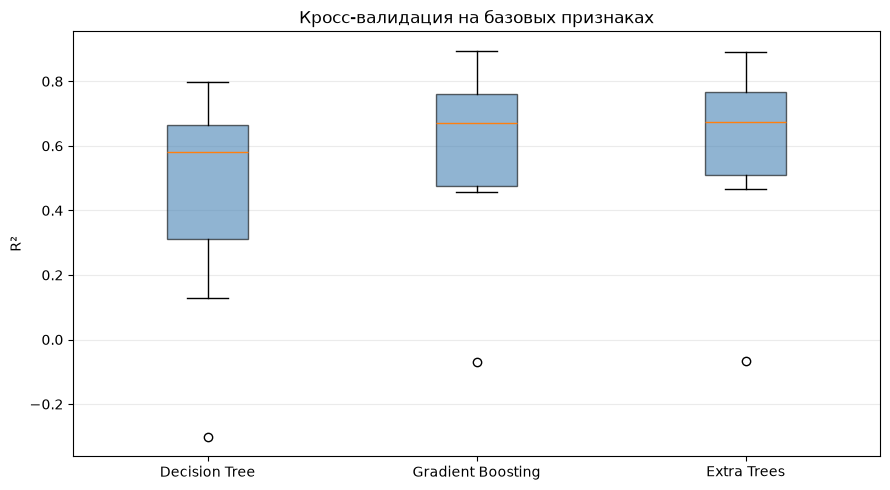

In [29]:
cv_results_base = {}

for name, model in models.items():
    cv_results_base[name] = cross_val_score(
        clone(model),
        X_train_base,
        y_train_model,
        cv=tscv,
        scoring="r2",
        n_jobs=1,
    )

cv_base_table = pl.DataFrame({
    "Модель": list(cv_results_base),
    "Среднее R2": [
        scores.mean() for scores in cv_results_base.values()
    ],
    "Стандартное отклонение": [
        scores.std() for scores in cv_results_base.values()
    ],
}).with_columns(
    pl.col(["Среднее R2", "Стандартное отклонение"]).round(4)
)

print(cv_base_table)

fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot(
    list(cv_results_base.values()),
    tick_labels=list(cv_results_base),
    patch_artist=True,
)
for patch in box["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.set_title("Кросс-валидация на базовых признаках")
ax.set_ylabel("R²")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Extra Trees показывает лучшее среднее R² при кросс-валидации. Разброс результатов между временными блоками заметен.

Decision Tree: R²=0.7719, MAE=0.7169, RMSE=0.9576, MAPE=2.60%


Gradient Boosting: R²=0.8428, MAE=0.6098, RMSE=0.7950, MAPE=2.22%


Extra Trees: R²=0.8278, MAE=0.6423, RMSE=0.8319, MAPE=2.33%
shape: (3, 6)
┌───────────────────┬────────┬────────┬────────┬────────┬────────┐
│ Модель            ┆ R2     ┆ MAE    ┆ MSE    ┆ RMSE   ┆ MAPE   │
│ ---               ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ str               ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════════════╪════════╪════════╪════════╪════════╪════════╡
│ Decision Tree     ┆ 0.7719 ┆ 0.7169 ┆ 0.9169 ┆ 0.9576 ┆ 2.605  │
│ Gradient Boosting ┆ 0.8428 ┆ 0.6098 ┆ 0.6321 ┆ 0.795  ┆ 2.2172 │
│ Extra Trees       ┆ 0.8278 ┆ 0.6423 ┆ 0.6921 ┆ 0.8319 ┆ 2.3334 │
└───────────────────┴────────┴────────┴────────┴────────┴────────┘


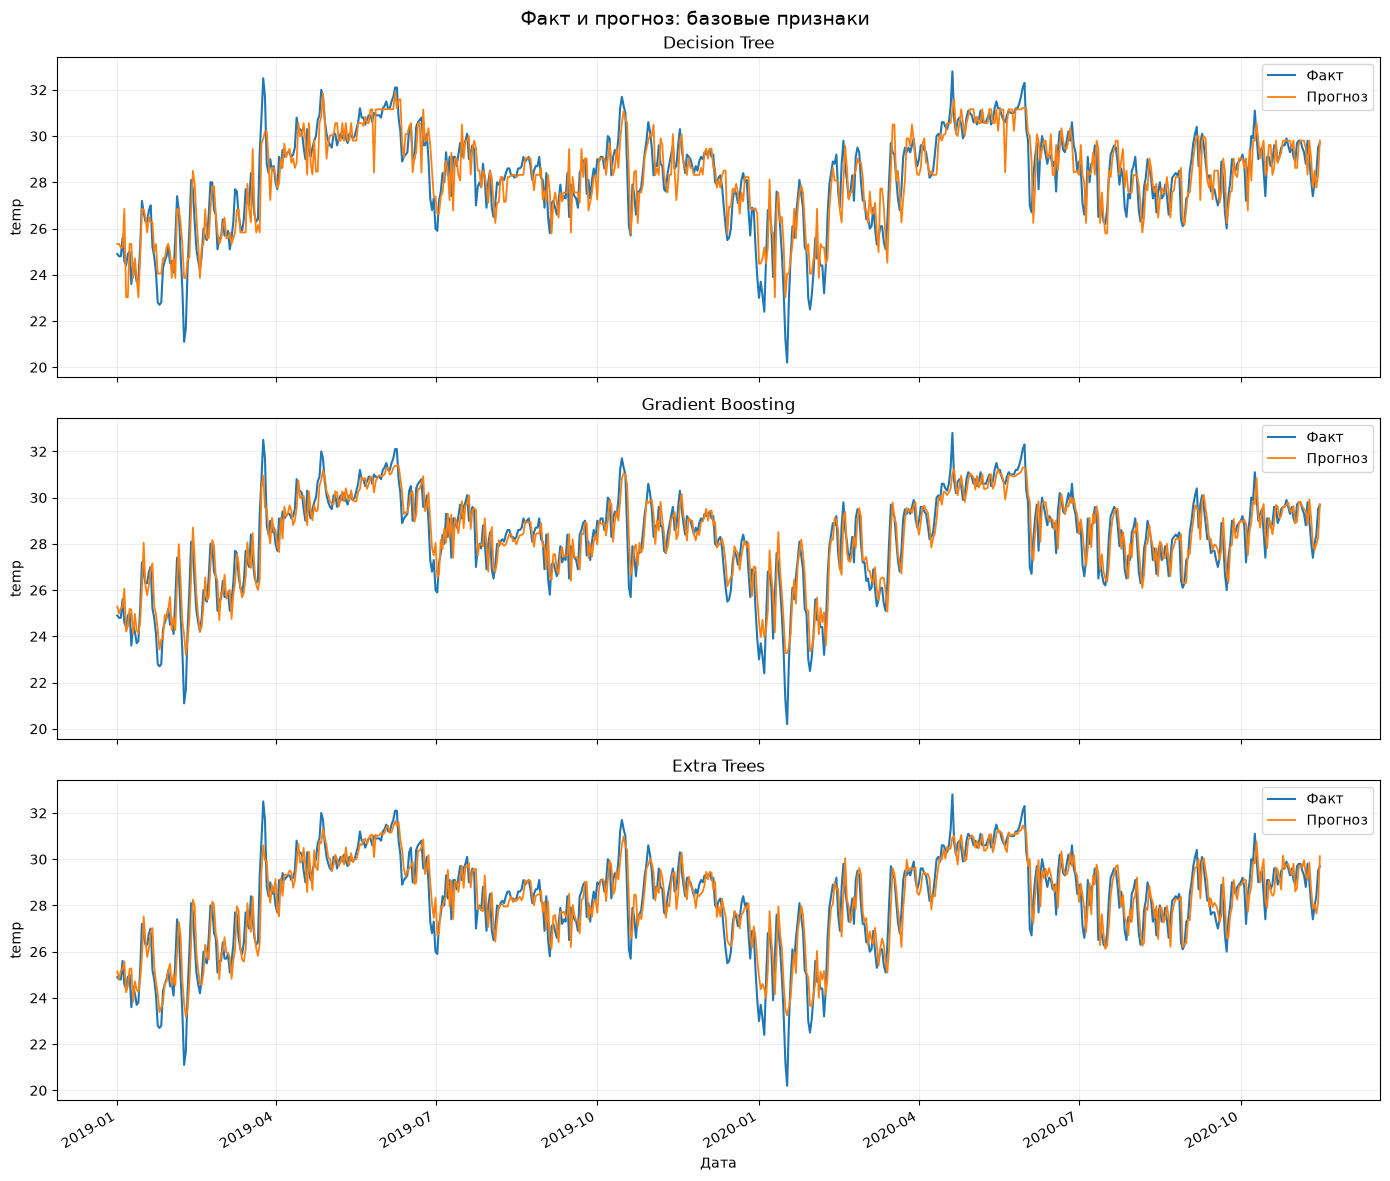

In [30]:
base_fitted_models = {}
base_predictions = {}
base_metrics = {}

for name, model in models.items():
    fitted_model = clone(model).fit(X_train_base, y_train_model)
    prediction = fitted_model.predict(X_test_base)

    base_fitted_models[name] = fitted_model
    base_predictions[name] = prediction
    base_metrics[name] = regression_results(
        y_test_model,
        prediction,
        name,
    )

base_metrics_table = pl.DataFrame([
    {"Модель": name, **base_metrics[name]}
    for name in models
]).select(
    ["Модель", "R2", "MAE", "MSE", "RMSE", "MAPE"]
).with_columns(
    pl.col(["R2", "MAE", "MSE", "RMSE", "MAPE"]).round(4)
)

print(base_metrics_table)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (name, prediction) in zip(axes, base_predictions.items()):
    ax.plot(test_dates, y_test_model, label="Факт", linewidth=1.5)
    ax.plot(test_dates, prediction, label="Прогноз", linewidth=1.3)
    ax.set_title(name)
    ax.set_ylabel("temp")
    ax.grid(alpha=0.2)
    ax.legend()

axes[-1].set_xlabel("Дата")
fig.suptitle("Факт и прогноз: базовые признаки", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

На тестовой выборке лучший результат показал Gradient Boosting: R² около 0.843.

## Задание 8. Обучение моделей на продвинутых признаках

Используются те же модели и тот же временной разрез. Изменяется только набор признаков.

shape: (3, 3)
┌───────────────────┬────────────┬────────────────────────┐
│ Модель            ┆ Среднее R2 ┆ Стандартное отклонение │
│ ---               ┆ ---        ┆ ---                    │
│ str               ┆ f64        ┆ f64                    │
╞═══════════════════╪════════════╪════════════════════════╡
│ Decision Tree     ┆ 0.3267     ┆ 0.3989                 │
│ Gradient Boosting ┆ 0.5816     ┆ 0.2652                 │
│ Extra Trees       ┆ 0.5827     ┆ 0.2304                 │
└───────────────────┴────────────┴────────────────────────┘


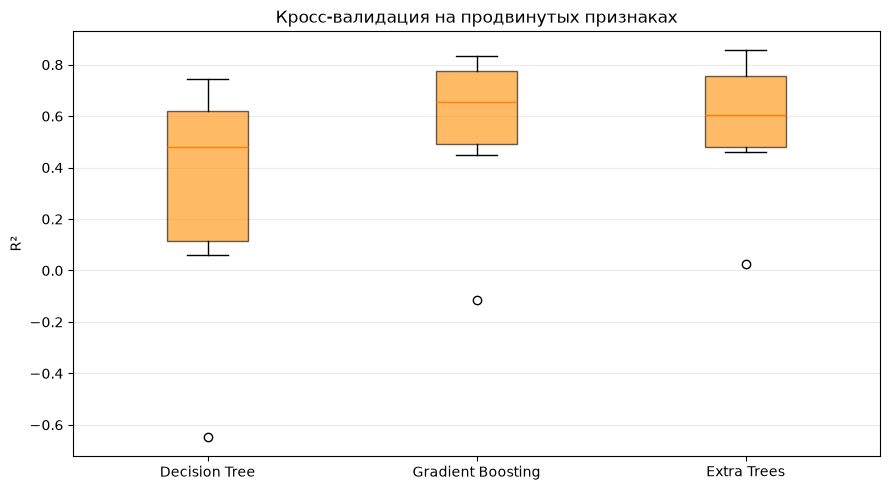

In [31]:
cv_results_adv = {}

for name, model in models.items():
    cv_results_adv[name] = cross_val_score(
        clone(model),
        X_train_adv,
        y_train_model,
        cv=tscv,
        scoring="r2",
        n_jobs=1,
    )

cv_adv_table = pl.DataFrame({
    "Модель": list(cv_results_adv),
    "Среднее R2": [
        scores.mean() for scores in cv_results_adv.values()
    ],
    "Стандартное отклонение": [
        scores.std() for scores in cv_results_adv.values()
    ],
}).with_columns(
    pl.col(["Среднее R2", "Стандартное отклонение"]).round(4)
)

print(cv_adv_table)

fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot(
    list(cv_results_adv.values()),
    tick_labels=list(cv_results_adv),
    patch_artist=True,
)
for patch in box["boxes"]:
    patch.set_facecolor("darkorange")
    patch.set_alpha(0.6)

ax.set_title("Кросс-валидация на продвинутых признаках")
ax.set_ylabel("R²")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Decision Tree: R²=0.7498, MAE=0.7641, RMSE=1.0029, MAPE=2.77%


Gradient Boosting: R²=0.8341, MAE=0.6209, RMSE=0.8167, MAPE=2.27%


Extra Trees: R²=0.8278, MAE=0.6339, RMSE=0.8319, MAPE=2.31%
shape: (3, 6)
┌───────────────────┬────────┬────────┬────────┬────────┬────────┐
│ Модель            ┆ R2     ┆ MAE    ┆ MSE    ┆ RMSE   ┆ MAPE   │
│ ---               ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ str               ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═══════════════════╪════════╪════════╪════════╪════════╪════════╡
│ Decision Tree     ┆ 0.7498 ┆ 0.7641 ┆ 1.0059 ┆ 1.0029 ┆ 2.7726 │
│ Gradient Boosting ┆ 0.8341 ┆ 0.6209 ┆ 0.667  ┆ 0.8167 ┆ 2.2663 │
│ Extra Trees       ┆ 0.8278 ┆ 0.6339 ┆ 0.6921 ┆ 0.8319 ┆ 2.3107 │
└───────────────────┴────────┴────────┴────────┴────────┴────────┘


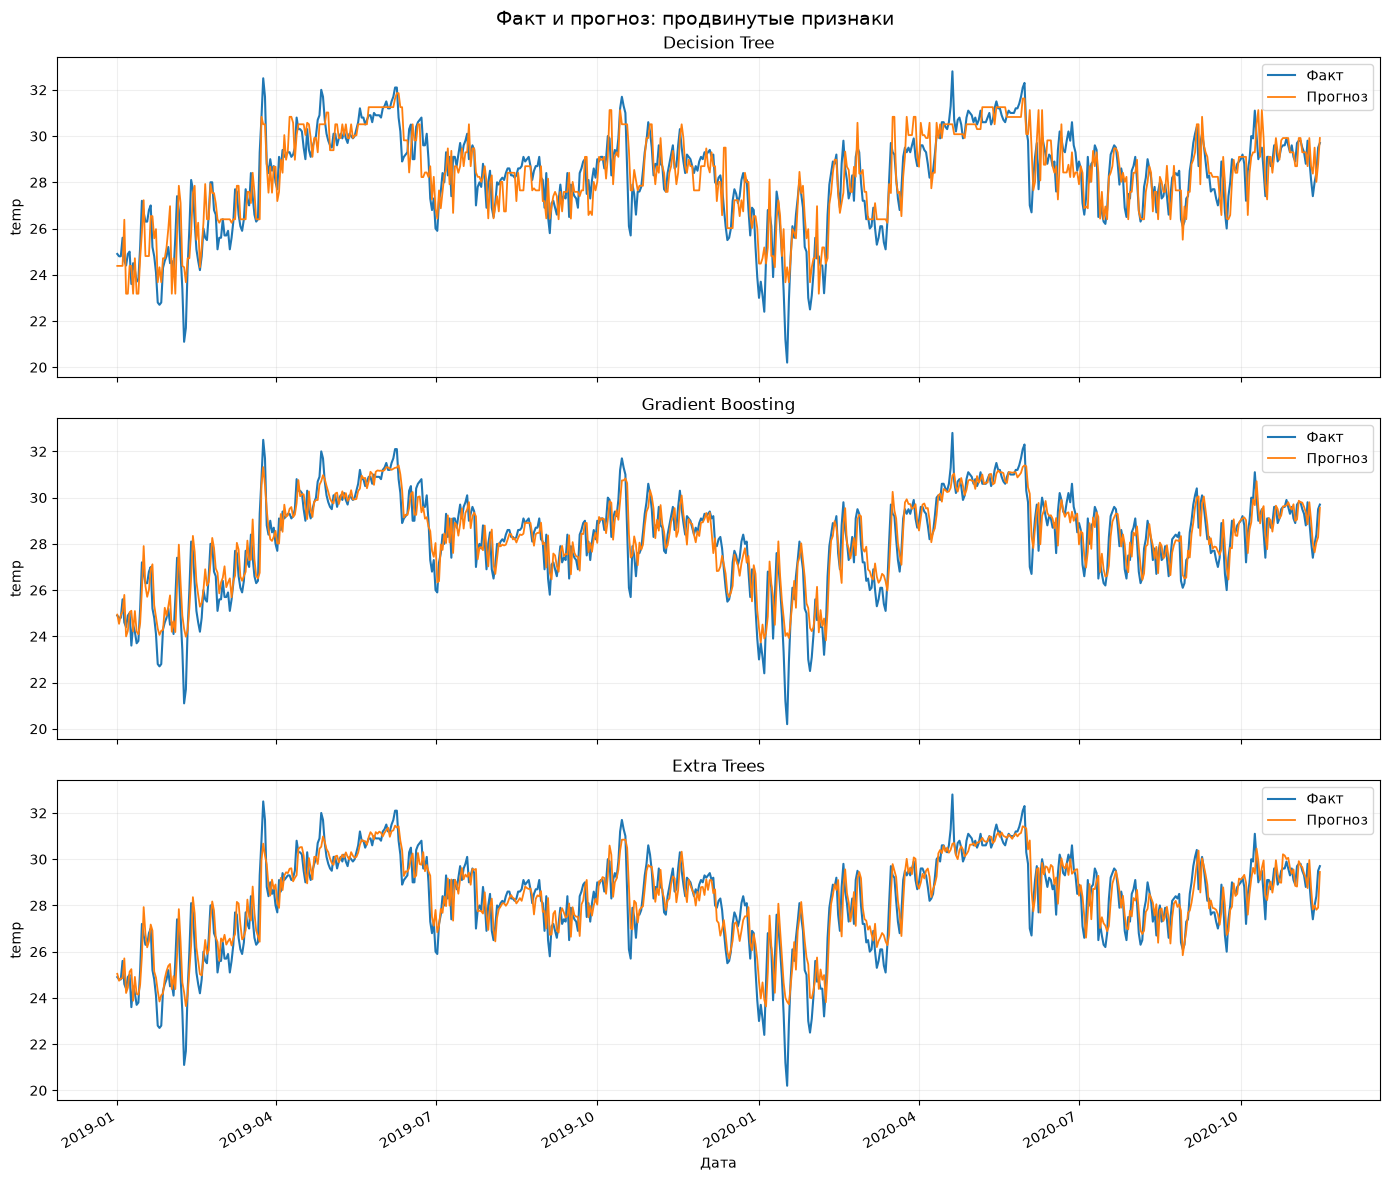

In [32]:
advanced_fitted_models = {}
advanced_predictions = {}
advanced_metrics = {}

for name, model in models.items():
    fitted_model = clone(model).fit(X_train_adv, y_train_model)
    prediction = fitted_model.predict(X_test_adv)

    advanced_fitted_models[name] = fitted_model
    advanced_predictions[name] = prediction
    advanced_metrics[name] = regression_results(
        y_test_model,
        prediction,
        name,
    )

advanced_metrics_table = pl.DataFrame([
    {"Модель": name, **advanced_metrics[name]}
    for name in models
]).select(
    ["Модель", "R2", "MAE", "MSE", "RMSE", "MAPE"]
).with_columns(
    pl.col(["R2", "MAE", "MSE", "RMSE", "MAPE"]).round(4)
)

print(advanced_metrics_table)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (name, prediction) in zip(axes, advanced_predictions.items()):
    ax.plot(test_dates, y_test_model, label="Факт", linewidth=1.5)
    ax.plot(test_dates, prediction, label="Прогноз", linewidth=1.3)
    ax.set_title(name)
    ax.set_ylabel("temp")
    ax.grid(alpha=0.2)
    ax.legend()

axes[-1].set_xlabel("Дата")
fig.suptitle("Факт и прогноз: продвинутые признаки", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Gradient Boosting снова стал лучшей моделью. Продвинутые признаки не улучшили лучший R² по сравнению с базовыми.

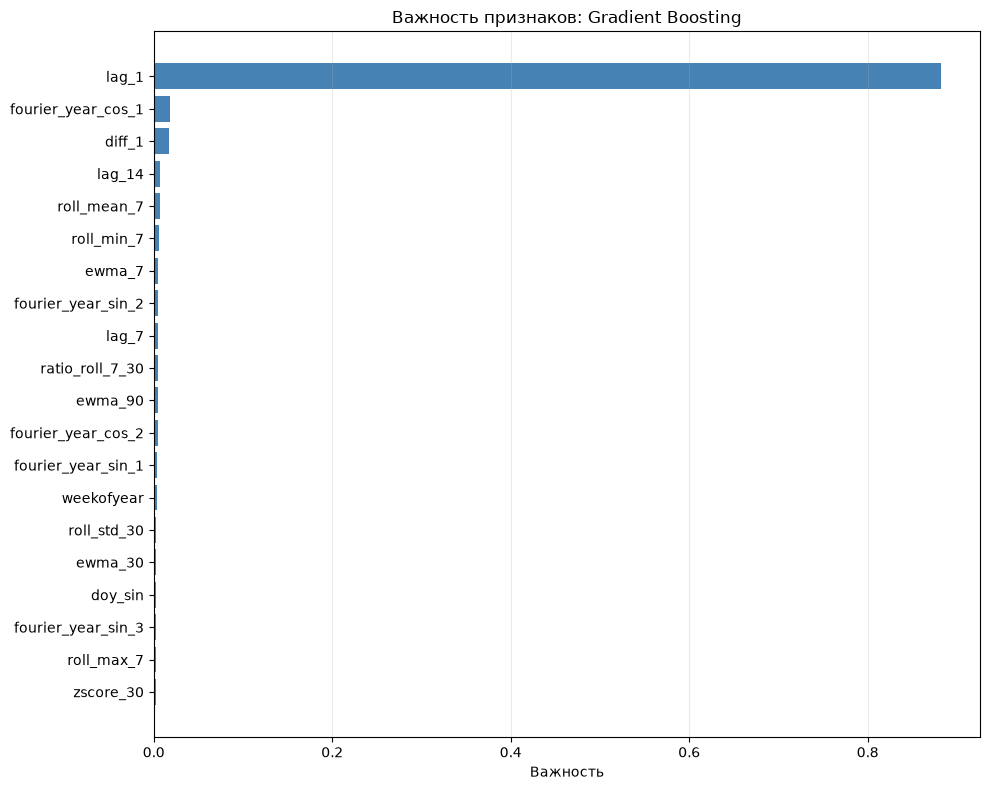

In [33]:
best_advanced_name = max(
    advanced_metrics,
    key=lambda name: advanced_metrics[name]["R2"],
)
best_advanced_model = advanced_fitted_models[best_advanced_name]

feature_importance = best_advanced_model.feature_importances_
top_positions = np.argsort(feature_importance)[-20:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [FEATURES_ADV[index] for index in top_positions],
    feature_importance[top_positions],
    color="steelblue",
)
ax.set_title(
    f"Важность признаков: {best_advanced_name}"
)
ax.set_xlabel("Важность")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

Самый важный признак — температура предыдущего дня lag_1. Его вклад значительно выше остальных признаков.

## Задание 9. Рекурсивный прогноз

В рекурсивном прогнозе каждое новое предсказание добавляется в историю и используется для следующего дня.

In [34]:
def ewm_last(values, span):
    """Последнее значение EWMA с adjust=True."""
    alpha = 2.0 / (span + 1.0)
    weights = (
        1.0 - alpha
    ) ** np.arange(len(values) - 1, -1, -1)
    return float(np.dot(weights, values) / weights.sum())


def make_recursive_feature_row(history_values, forecast_date):
    """Создаёт одну строку признаков из доступной истории."""
    values = np.asarray(history_values, dtype=float)
    time_index = len(values)

    dayofweek = forecast_date.weekday() + 1
    month = forecast_date.month
    dayofyear = forecast_date.timetuple().tm_yday

    roll_7 = values[-7:]
    roll_30 = values[-30:]

    ewma_7 = ewm_last(values, 7)
    ewma_30 = ewm_last(values, 30)
    ewma_90 = ewm_last(values, 90)

    roll_mean_7 = float(np.mean(roll_7))
    roll_mean_30 = float(np.mean(roll_30))
    roll_std_30 = float(np.std(roll_30, ddof=1))

    row = {
        "lag_1": values[-1],
        "lag_7": values[-7],
        "lag_14": values[-14],
        "lag_30": values[-30],
        "diff_1": values[-1] - values[-2],
        "diff_7": values[-1] - values[-8],
        "ratio_7": values[-1] / values[-8],
        "dayofweek": dayofweek,
        "month": month,
        "quarter": (month - 1) // 3 + 1,
        "dayofyear": dayofyear,
        "weekofyear": forecast_date.isocalendar().week,
        "day": forecast_date.day,
        "dow_sin": np.sin(
            2 * np.pi * dayofweek / WEEK_PERIOD
        ),
        "dow_cos": np.cos(
            2 * np.pi * dayofweek / WEEK_PERIOD
        ),
        "month_sin": np.sin(
            2 * np.pi * month / MONTH_PERIOD
        ),
        "month_cos": np.cos(
            2 * np.pi * month / MONTH_PERIOD
        ),
        "doy_sin": np.sin(
            2 * np.pi * dayofyear / YEAR_PERIOD
        ),
        "doy_cos": np.cos(
            2 * np.pi * dayofyear / YEAR_PERIOD
        ),
        "roll_mean_7": roll_mean_7,
        "roll_mean_30": roll_mean_30,
        "roll_std_7": float(np.std(roll_7, ddof=1)),
        "roll_std_30": roll_std_30,
        "roll_min_7": float(np.min(roll_7)),
        "roll_max_7": float(np.max(roll_7)),
        "ewma_7": ewma_7,
        "ewma_30": ewma_30,
        "ewma_90": ewma_90,
        "dev_ewma_30": values[-1] - ewma_30,
        "ratio_roll_7_30": roll_mean_7 / roll_mean_30,
        "zscore_30": (
            0.0
            if roll_std_30 == 0
            else (values[-1] - roll_mean_30) / roll_std_30
        ),
        "is_weekend": int(dayofweek in (6, 7)),
        "is_winter": int(month in (12, 1, 2)),
    }

    for k in range(1, 4):
        row[f"fourier_week_sin_{k}"] = np.sin(
            2 * np.pi * k * time_index / WEEK_PERIOD
        )
        row[f"fourier_week_cos_{k}"] = np.cos(
            2 * np.pi * k * time_index / WEEK_PERIOD
        )
        row[f"fourier_year_sin_{k}"] = np.sin(
            2 * np.pi * k * time_index / YEAR_PERIOD
        )
        row[f"fourier_year_cos_{k}"] = np.cos(
            2 * np.pi * k * time_index / YEAR_PERIOD
        )

    return np.asarray(
        [[row[name] for name in FEATURES_ADV]],
        dtype=float,
    )


def recursive_forecast(model, history_frame, forecast_dates):
    """Прогнозирует даты последовательно без фактических будущих значений."""
    history_values = (
        history_frame
        .sort("datetime")
        .get_column("temp")
        .to_list()
    )
    predictions = []

    for forecast_date in forecast_dates:
        feature_row = make_recursive_feature_row(
            history_values,
            forecast_date,
        )
        prediction = float(model.predict(feature_row)[0])
        predictions.append(prediction)
        history_values.append(prediction)

    return np.asarray(predictions)

In [35]:
history_for_recursive = (
    data_df
    .filter(pl.col("datetime") < split_date)
    .select(["datetime", "temp"])
)

recursive_prediction = recursive_forecast(
    best_advanced_model,
    history_for_recursive,
    test_dates,
)

direct_prediction = advanced_predictions[best_advanced_name]
direct_metrics = advanced_metrics[best_advanced_name]
recursive_metrics = regression_results(
    y_test_model,
    recursive_prediction,
    f"{best_advanced_name}, рекурсивный",
)

comparison_forecast_table = pl.DataFrame([
    {
        "Подход": "Прямой",
        **direct_metrics,
    },
    {
        "Подход": "Рекурсивный",
        **recursive_metrics,
    },
]).select(
    ["Подход", "R2", "MAE", "MSE", "RMSE", "MAPE"]
).with_columns(
    pl.col(["R2", "MAE", "MSE", "RMSE", "MAPE"]).round(4)
)

print(comparison_forecast_table)

Gradient Boosting, рекурсивный: R²=0.2353, MAE=1.4836, RMSE=1.7533, MAPE=5.19%
shape: (2, 6)
┌─────────────┬────────┬────────┬────────┬────────┬────────┐
│ Подход      ┆ R2     ┆ MAE    ┆ MSE    ┆ RMSE   ┆ MAPE   │
│ ---         ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ str         ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═════════════╪════════╪════════╪════════╪════════╪════════╡
│ Прямой      ┆ 0.8341 ┆ 0.6209 ┆ 0.667  ┆ 0.8167 ┆ 2.2663 │
│ Рекурсивный ┆ 0.2353 ┆ 1.4836 ┆ 3.0741 ┆ 1.7533 ┆ 5.1947 │
└─────────────┴────────┴────────┴────────┴────────┴────────┘


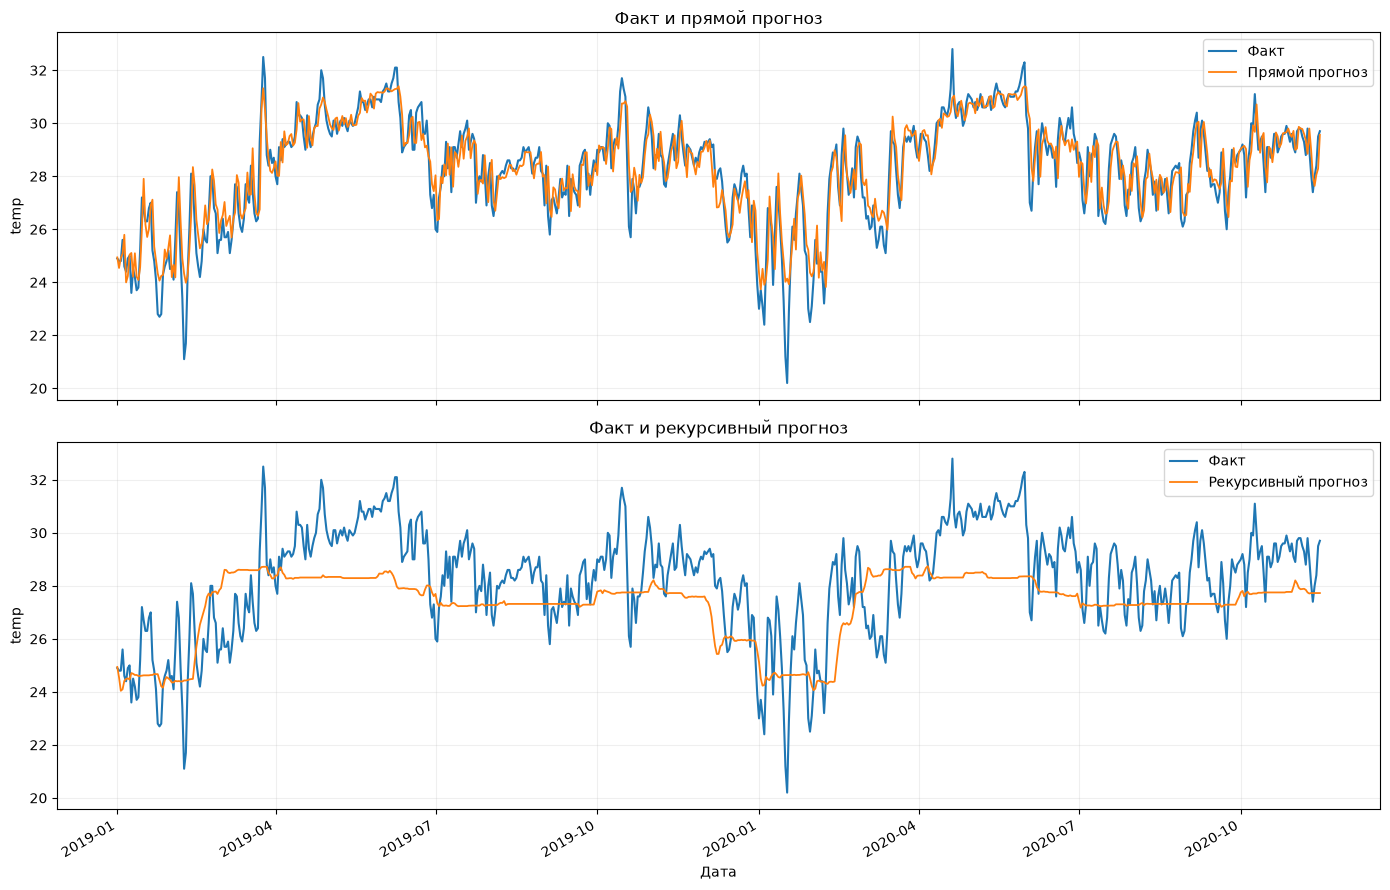

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    test_dates,
    y_test_model,
    label="Факт",
    linewidth=1.5,
)
axes[0].plot(
    test_dates,
    direct_prediction,
    label="Прямой прогноз",
    linewidth=1.3,
)
axes[0].set_title("Факт и прямой прогноз")
axes[0].set_ylabel("temp")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(
    test_dates,
    y_test_model,
    label="Факт",
    linewidth=1.5,
)
axes[1].plot(
    test_dates,
    recursive_prediction,
    label="Рекурсивный прогноз",
    linewidth=1.3,
)
axes[1].set_title("Факт и рекурсивный прогноз")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("temp")
axes[1].grid(alpha=0.2)
axes[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Рекурсивный прогноз заметно хуже прямого. Ошибки постепенно накапливаются, потому что модель использует собственные прошлые прогнозы.

## Задание 10. Взвешенный ансамбль

Вес каждой модели обратно пропорционален её MSE. Сумма весов равна единице.

Взвешенный ансамбль: R²=0.8286, MAE=0.6332, RMSE=0.8302, MAPE=2.31%
shape: (3, 2)
┌───────────────────┬────────┐
│ Модель            ┆ Вес    │
│ ---               ┆ ---    │
│ str               ┆ f64    │
╞═══════════════════╪════════╡
│ Decision Tree     ┆ 0.2524 │
│ Gradient Boosting ┆ 0.3807 │
│ Extra Trees       ┆ 0.3669 │
└───────────────────┴────────┘


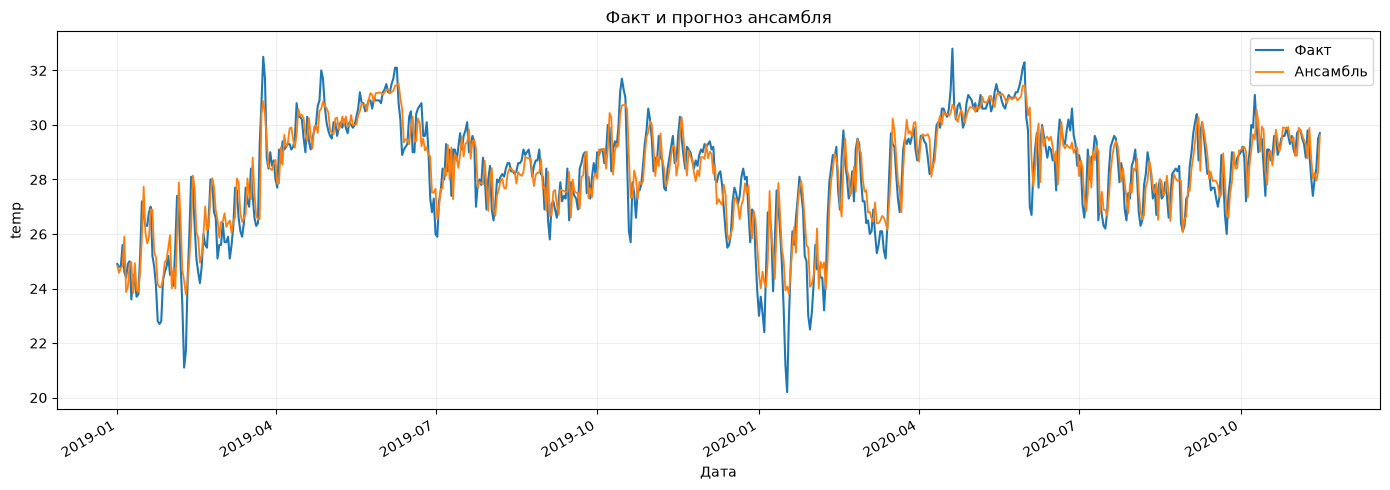

In [37]:
inverse_mse = {
    name: 1.0 / (advanced_metrics[name]["MSE"] + 1e-8)
    for name in models
}

weight_sum = sum(inverse_mse.values())

ensemble_weights = {
    name: value / weight_sum
    for name, value in inverse_mse.items()
}

ensemble_prediction = sum(
    ensemble_weights[name] * advanced_predictions[name]
    for name in models
)

ensemble_metrics = regression_results(
    y_test_model,
    ensemble_prediction,
    "Взвешенный ансамбль",
)

weights_table = pl.DataFrame({
    "Модель": list(ensemble_weights),
    "Вес": list(ensemble_weights.values()),
}).with_columns(
    pl.col("Вес").round(4)
)

print(weights_table)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test_model, label="Факт", linewidth=1.5)
ax.plot(
    test_dates,
    ensemble_prediction,
    label="Ансамбль",
    linewidth=1.3,
)
ax.set_title("Факт и прогноз ансамбля")
ax.set_xlabel("Дата")
ax.set_ylabel("temp")
ax.grid(alpha=0.2)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Наибольший вес получил Gradient Boosting. Ансамбль работает стабильно, но не превзошёл лучшую отдельную модель.

## Задание 11. Итоговая сводка

В таблице сравниваются базовые и продвинутые признаки, прямой и рекурсивный прогнозы, а также ансамбль.

shape: (8, 6)
┌──────────────────────┬───────────────────┬────────┬────────┬────────┬────────┐
│ Подход               ┆ Модель            ┆ R2     ┆ MAE    ┆ RMSE   ┆ MAPE   │
│ ---                  ┆ ---               ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ str                  ┆ str               ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞══════════════════════╪═══════════════════╪════════╪════════╪════════╪════════╡
│ Базовые признаки     ┆ Decision Tree     ┆ 0.7719 ┆ 0.7169 ┆ 0.9576 ┆ 2.605  │
│ Продвинутые признаки ┆ Decision Tree     ┆ 0.7498 ┆ 0.7641 ┆ 1.0029 ┆ 2.7726 │
│ Базовые признаки     ┆ Gradient Boosting ┆ 0.8428 ┆ 0.6098 ┆ 0.795  ┆ 2.2172 │
│ Продвинутые признаки ┆ Gradient Boosting ┆ 0.8341 ┆ 0.6209 ┆ 0.8167 ┆ 2.2663 │
│ Базовые признаки     ┆ Extra Trees       ┆ 0.8278 ┆ 0.6423 ┆ 0.8319 ┆ 2.3334 │
│ Продвинутые признаки ┆ Extra Trees       ┆ 0.8278 ┆ 0.6339 ┆ 0.8319 ┆ 2.3107 │
│ Рекурсивный прогноз  ┆ Gradient Boosting ┆ 0.2353 ┆ 1.4836 ┆ 1.7533 ┆ 5.1947 │
│ Взвешенный а

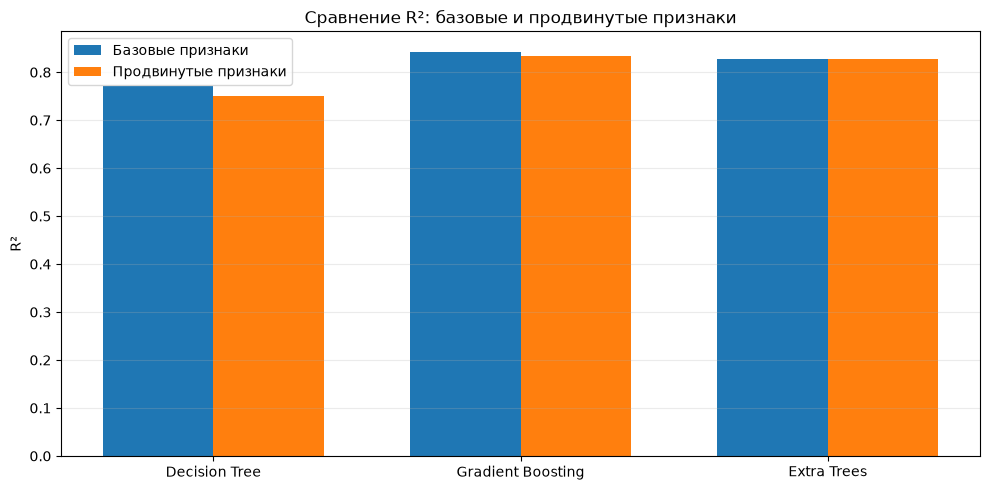

In [38]:
summary_rows = []

for name in models:
    summary_rows.append({
        "Подход": "Базовые признаки",
        "Модель": name,
        **base_metrics[name],
    })
    summary_rows.append({
        "Подход": "Продвинутые признаки",
        "Модель": name,
        **advanced_metrics[name],
    })

summary_rows.append({
    "Подход": "Рекурсивный прогноз",
    "Модель": best_advanced_name,
    **recursive_metrics,
})

summary_rows.append({
    "Подход": "Взвешенный ансамбль",
    "Модель": "Ensemble",
    **ensemble_metrics,
})

summary_table = (
    pl.DataFrame(summary_rows)
    .select(["Подход", "Модель", "R2", "MAE", "RMSE", "MAPE"])
    .with_columns(
        pl.col(["R2", "MAE", "RMSE", "MAPE"]).round(4)
    )
)

print(summary_table)

model_names = list(models)
x_positions = np.arange(len(model_names))
bar_width = 0.36

base_r2 = [
    base_metrics[name]["R2"]
    for name in model_names
]
advanced_r2 = [
    advanced_metrics[name]["R2"]
    for name in model_names
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    x_positions - bar_width / 2,
    base_r2,
    width=bar_width,
    label="Базовые признаки",
)
ax.bar(
    x_positions + bar_width / 2,
    advanced_r2,
    width=bar_width,
    label="Продвинутые признаки",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(model_names)
ax.set_ylabel("R²")
ax.set_title("Сравнение R²: базовые и продвинутые признаки")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Итоговые выводы

- Лучший результат дал Gradient Boosting на базовых признаках: R² ≈ 0.843.
- Продвинутые признаки не улучшили лучший результат.
- Самым важным признаком оказался lag_1.
- Рекурсивный прогноз слабее прямого из-за накопления ошибок.
- Ансамбль не превзошёл Gradient Boosting.